In [169]:
import pandas as pd
from pymatgen.core.composition import Composition

In [170]:
data = pd.read_csv('./data/data.csv')
def get_composition(composition):
    return Composition(composition).fractional_composition
data['composition'] = data['composition'].apply(get_composition)


In [171]:
param = 'ΔH'
unit = 'kJ/mol'
data = data.dropna(subset=[param])

# 特征工程

## 原子的摩尔分数

In [172]:
elements_list = ['V', 'Cu', 'Ce', 'Zr', 'Co', 'W', 'Mn', 'Mo', 'Cr', 'Sn', 'Ni', 'Gd', 'La', 'Ti', 'Si', 'B', 'Nb', 'Y', 'Fe', 'Al', 'Mg', 'C']
for element in elements_list:
    def get_atomic_fraction(comps):
        return comps.get_atomic_fraction(element)
    data[element] = data['composition'].apply(get_atomic_fraction)


# Training model

In [173]:
from sklearn import metrics
from sklearn.model_selection import cross_validate, train_test_split
# import scikitplot as skplt
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn import svm

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from sklearn.utils import shuffle
from matplotlib import pyplot as plt
from matplotlib import rcParams

rcParams['font.family']='sans-serif'
plt.rcParams['font.sans-serif'] = ['Times New Roman']  # 如果要显示中文字体,则在此处设为：SimHei
plt.rcParams['axes.unicode_minus'] = False  # 显示负号
RNG_SEED = 10

In [174]:
data

,composition,ΔH,ΔS,C14,C15,wt,ln_p,V,Cu,Ce,...,La,Ti,Si,B,Nb,Y,Fe,Al,Mg,C
0,"{Ti: 0.3333333333333333, Mn: 0.283333332833333...",14.70,93.7,100.0,0.0,NaN,-11.199423,0.016667,0.0,0.0,...,0.000000,0.333333,0.0,0.0,0.0,0.0,0.033333,0.000000,0.0,0.0
1,"{Ti: 0.3333333333333333, Mn: 0.233333332333333...",17.70,101.0,100.0,0.0,NaN,-12.063026,0.033333,0.0,0.0,...,0.000000,0.333333,0.0,0.0,0.0,0.0,0.066667,0.000000,0.0,0.0
2,"{Ti: 0.3333333333333333, Mn: 0.183333331833333...",18.60,99.9,100.0,0.0,NaN,-11.926389,0.050000,0.0,0.0,...,0.000000,0.333333,0.0,0.0,0.0,0.0,0.100000,0.000000,0.0,0.0
3,"{Ti: 0.3333333333333333, Mn: 0.133333331333333...",20.20,103.0,100.0,0.0,NaN,-12.291556,0.066667,0.0,0.0,...,0.000000,0.333333,0.0,0.0,0.0,0.0,0.133333,0.000000,0.0,0.0
4,"{Zr: 0.013468010134680103, Ti: 0.3198653231986...",15.10,93.0,100.0,0.0,NaN,-11.113303,0.000000,0.0,0.0,...,0.000000,0.319865,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309,"{La: 0.2984693870153062, Zr: 0.214067277859327...",36.82,110.0,0.0,0.0,1.27,-13.053548,0.057823,0.0,0.0,...,0.298469,0.119266,0.0,0.0,0.0,0.0,0.000000,0.005952,0.0,0.0
310,"{La: 0.21447720785522795, Zr: 0.21437908785620...",36.72,110.0,0.0,0.0,1.33,-13.054029,0.071492,0.0,0.0,...,0.214477,0.118954,0.0,0.0,0.0,0.0,0.000000,0.007149,0.0,0.0
311,"{La: 0.25896763, Zr: 0.2137834, Ti: 0.11954993...",37.03,110.0,0.0,0.0,1.38,-13.052538,0.064742,0.0,0.0,...,0.258968,0.119550,0.0,0.0,0.0,0.0,0.000000,0.006124,0.0,0.0
312,"{La: 0.20911527999999993, Zr: 0.21307189999999...",34.83,110.0,0.0,0.0,1.24,-13.063122,0.071492,0.0,0.0,...,0.209115,0.120261,0.0,0.0,0.0,0.0,0.000000,0.007149,0.0,0.0


In [175]:
X = data.iloc[:, 7:].to_numpy()
y = data[param].to_numpy()
minmax_scaler = MinMaxScaler()
X = minmax_scaler.fit_transform(X)
X, y = shuffle(X, y, random_state=RNG_SEED)
print(X.shape, y.shape)

(314, 22) (314,)


In [176]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RNG_SEED) 
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(251, 22) (63, 22)
(251,) (63,)


# RF

In [177]:
rf_model = RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=RNG_SEED)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

Random Forest:
R2:  0.6604438220832164
MAE:  4.1793999004699005
test_neg_mean_absolute_error:  -4.704680911310826
test_r2:  0.5199823242337007


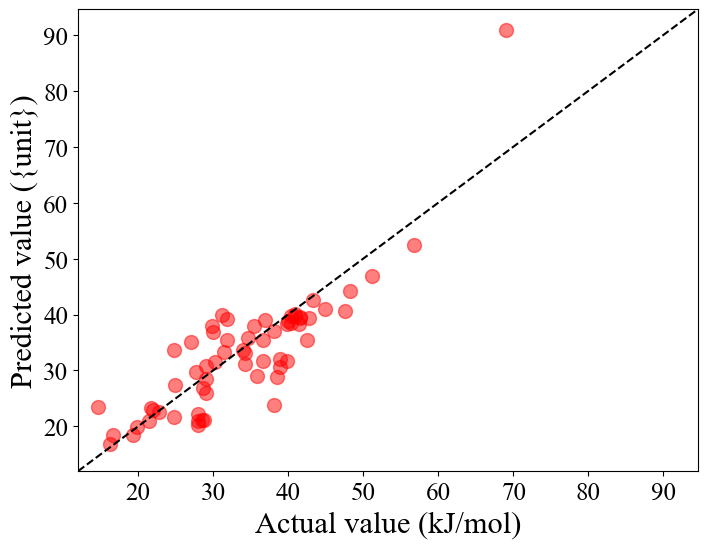

In [178]:
print("Random Forest:")
y_pred = rf_model.predict(X_test)
print('R2: ', rf_model.score(X_test, y_test))  # sklearnrint("MSE: ", mean_squared_error(y_test, model.predict(X_test))) # mse
print("MAE: ", metrics.mean_absolute_error(y_test, y_pred))

cv = cross_validate(rf_model, X, y, cv=5, scoring=('neg_mean_absolute_error', 'r2'), n_jobs=-1)
print('test_neg_mean_absolute_error: ', np.mean(cv['test_neg_mean_absolute_error']))
print('test_r2: ', np.mean(cv['test_r2']))

plt.figure(figsize=(8, 6))
# act_pred(y_test, y_pred, x_hist=False, y_hist=False)
plt.scatter(y_test, y_pred, alpha=0.5, color='red', s=100, label='RF')
plt.xlabel(f'Actual value ({unit})', fontsize=22)
plt.ylabel('Predicted value ({unit})', fontsize=22)
# plt.legend(fontsize=18)
xlim = plt.xlim()
ylim = plt.ylim()
lims = [min(xlim[0], ylim[0]), max(xlim[1], ylim[1])]
min_val = lims[0]
max_val = lims[1]
# 确定对角线的坐标
diag_x = [min_val, max_val]
diag_y = [min_val, max_val]
plt.plot(diag_x, diag_y, linestyle='--', color='black')
plt.xlim(lims[0], lims[1])
plt.ylim(lims[0], lims[1])
plt.xticks(fontsize=18)
# 设置 y 轴刻度标签的大小
plt.yticks(fontsize=18)
plt.savefig(f"./figures/RF_{param}.jpg", dpi=600)


# NN

In [179]:
mlp_model = MLPRegressor(hidden_layer_sizes=(50, 50, 100, 100, 50, 50), random_state=RNG_SEED)
mlp_model.fit(X_train, y_train)

/home/clqin/.conda/envs/cq/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


MLP:
R2:  0.6423997647932322
MAE:  4.831882076348886


/home/clqin/.conda/envs/cq/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/clqin/.conda/envs/cq/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/clqin/.conda/envs/cq/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/clqin/.conda/envs/cq/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/clqin/.conda/e

test_neg_mean_absolute_error:  -6.088298896122882
test_r2:  0.23067191381006508


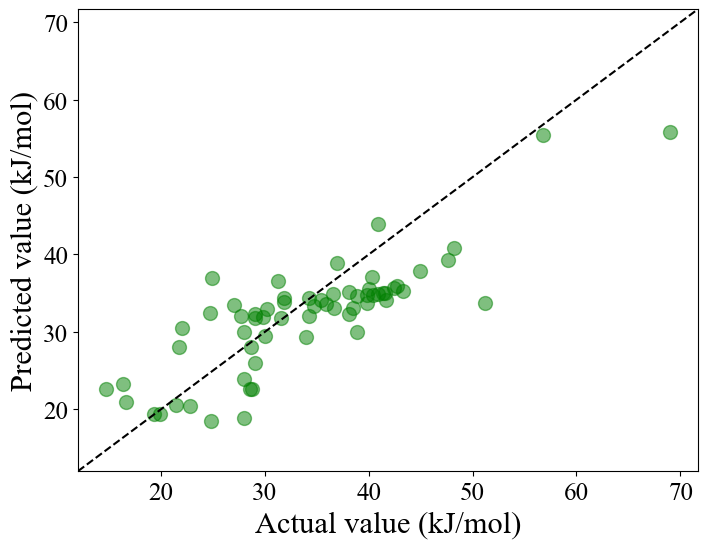

In [180]:
print("MLP:")
y_pred = mlp_model.predict(X_test)
print('R2: ', mlp_model.score(X_test, y_test))  # sklearnrint("MSE: ", mean_squared_error(y_test, model.predict(X_test))) # mse
print("MAE: ", metrics.mean_absolute_error(y_test, y_pred))

cv = cross_validate(mlp_model, X, y, cv=5, scoring=('neg_mean_absolute_error', 'r2'), n_jobs=-1)
print('test_neg_mean_absolute_error: ', np.mean(cv['test_neg_mean_absolute_error']))
print('test_r2: ', np.mean(cv['test_r2']))

plt.figure(figsize=(8, 6))
# act_pred(y_test, y_pred, x_hist=False, y_hist=False)
plt.scatter(y_test, y_pred, alpha=0.5, color='green', s=100, label='MLP')
plt.xlabel(f'Actual value ({unit})', fontsize=22)
plt.ylabel(f'Predicted value ({unit})', fontsize=22)
xlim = plt.xlim()
ylim = plt.ylim()
lims = [min(xlim[0], ylim[0]), max(xlim[1], ylim[1])]
min_val = lims[0]
max_val = lims[1]
# 确定对角线的坐标
diag_x = [min_val, max_val]
diag_y = [min_val, max_val]
plt.plot(diag_x, diag_y, linestyle='--', color='black')
plt.xlim(lims[0], lims[1])
plt.ylim(lims[0], lims[1])
plt.xticks(fontsize=18)
# 设置 y 轴刻度标签的大小
plt.yticks(fontsize=18)
plt.savefig(f"./figures/MLP_{param}.jpg", dpi=600)

# ET

In [181]:
et_model = ExtraTreesRegressor(n_estimators=50, random_state=RNG_SEED)
et_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the n

ET:
R2:  0.6166561803396151
MAE:  3.985659300831447
test_neg_mean_absolute_error:  -4.006147694913809
test_r2:  0.5998305983644089


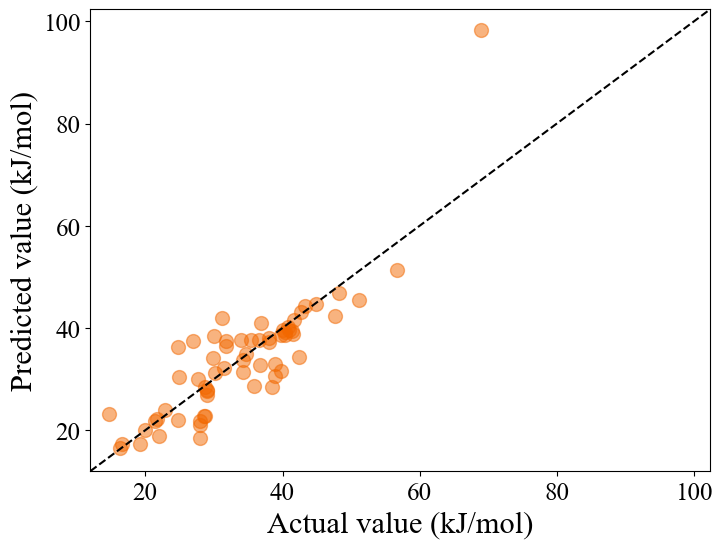

In [182]:
print("ET:")
y_pred = et_model.predict(X_test)
print('R2: ', et_model.score(X_test, y_test))  # sklearnrint("MSE: ", mean_squared_error(y_test, model.predict(X_test))) # mse
print("MAE: ", metrics.mean_absolute_error(y_test, y_pred))

cv = cross_validate(et_model, X, y, cv=5, scoring=('neg_mean_absolute_error', 'r2'), n_jobs=-1)
print('test_neg_mean_absolute_error: ', np.mean(cv['test_neg_mean_absolute_error']))
print('test_r2: ', np.mean(cv['test_r2']))

plt.figure(figsize=(8, 6))
# act_pred(y_test, y_pred, x_hist=False, y_hist=False)
plt.scatter(y_test, y_pred, alpha=0.5, color='#F26800', s=100, label='ET')
plt.xlabel(f'Actual value ({unit})', fontsize=22)
plt.ylabel(f'Predicted value ({unit})', fontsize=22)

xlim = plt.xlim()
ylim = plt.ylim()
lims = [min(xlim[0], ylim[0]), max(xlim[1], ylim[1])]
min_val = lims[0]
max_val = lims[1]
# 确定对角线的坐标
diag_x = [min_val, max_val]
diag_y = [min_val, max_val]
plt.plot(diag_x, diag_y, linestyle='--', color='black')
plt.xlim(lims[0], lims[1])
plt.ylim(lims[0], lims[1])
plt.xticks(fontsize=18)
# 设置 y 轴刻度标签的大小
plt.yticks(fontsize=18)
plt.savefig(f"./figures/ET_{param}.jpg", dpi=600)

# SVM

In [183]:
rbf_svr_model = svm.SVR(kernel='rbf', C=100)
rbf_svr_model.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


SVM:
R2:  0.4654972273765351
MAE:  4.026090904398063
test_neg_mean_absolute_error:  -5.282671047189918
test_r2:  0.3339064760800774


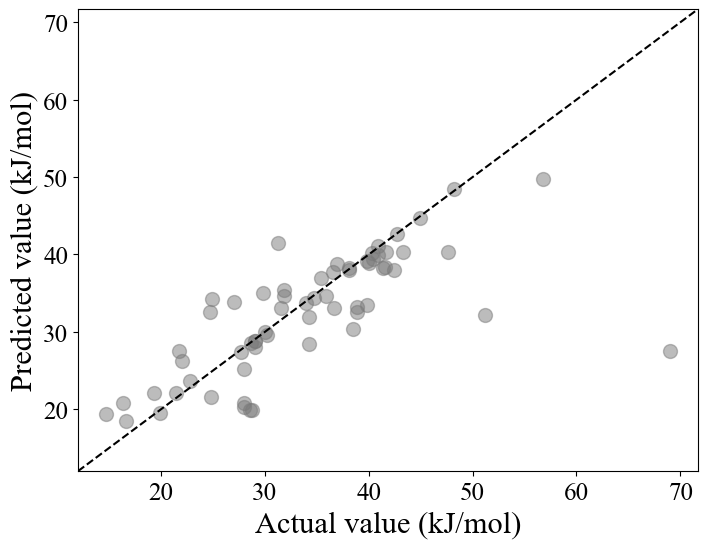

In [184]:
print("SVM:")
y_pred = rbf_svr_model.predict(X_test)
print('R2: ', rbf_svr_model.score(X_test, y_test))  # sklearnrint("MSE: ", mean_squared_error(y_test, model.predict(X_test))) # mse
print("MAE: ", metrics.mean_absolute_error(y_test, y_pred))

cv = cross_validate(rbf_svr_model, X, y, cv=5, scoring=('neg_mean_absolute_error', 'r2'), n_jobs=-1)
print('test_neg_mean_absolute_error: ', np.mean(cv['test_neg_mean_absolute_error']))
print('test_r2: ', np.mean(cv['test_r2']))

plt.figure(figsize=(8, 6))
# act_pred(y_test, y_pred, x_hist=False, y_hist=False)
plt.scatter(y_test, y_pred, alpha=0.5, color='#7A7A7A', s=100, label='SVM')
plt.xlabel(f'Actual value ({unit})', fontsize=22)
plt.ylabel(f'Predicted value ({unit})', fontsize=22)

xlim = plt.xlim()
ylim = plt.ylim()
lims = [min(xlim[0], ylim[0]), max(xlim[1], ylim[1])]
min_val = lims[0]
max_val = lims[1]
# 确定对角线的坐标
diag_x = [min_val, max_val]
diag_y = [min_val, max_val]
plt.plot(diag_x, diag_y, linestyle='--', color='black')
plt.xlim(lims[0], lims[1])
plt.ylim(lims[0], lims[1])
plt.xticks(fontsize=18)
# 设置 y 轴刻度标签的大小
plt.yticks(fontsize=18)
plt.savefig(f"./figures/SVM_{param}.jpg", dpi=600)

# 存储模型

In [ ]:
X = data.iloc[:, 7:].to_numpy()
y = data[param].to_numpy()
minmax_scaler = MinMaxScaler()
X = minmax_scaler.fit_transform(X)
et_model = RandomForestRegressor(n_estimators=50, random_state=RNG_SEED)
# et_model = ExtraTreesRegressor(n_estimators=50, random_state=RNG_SEED)
et_model.fit(X, y)

,composition,ΔH,ΔS,C14,C15,wt,ln_p,V,Cu,Ce,...,La,Ti,Si,B,Nb,Y,Fe,Al,Mg,C
0,"{Ti: 0.3333333333333333, Mn: 0.283333332833333...",14.70,93.7,100.0,0.0,NaN,-11.199423,0.016667,0.0,0.0,...,0.000000,0.333333,0.0,0.0,0.0,0.0,0.033333,0.000000,0.0,0.0
1,"{Ti: 0.3333333333333333, Mn: 0.233333332333333...",17.70,101.0,100.0,0.0,NaN,-12.063026,0.033333,0.0,0.0,...,0.000000,0.333333,0.0,0.0,0.0,0.0,0.066667,0.000000,0.0,0.0
2,"{Ti: 0.3333333333333333, Mn: 0.183333331833333...",18.60,99.9,100.0,0.0,NaN,-11.926389,0.050000,0.0,0.0,...,0.000000,0.333333,0.0,0.0,0.0,0.0,0.100000,0.000000,0.0,0.0
3,"{Ti: 0.3333333333333333, Mn: 0.133333331333333...",20.20,103.0,100.0,0.0,NaN,-12.291556,0.066667,0.0,0.0,...,0.000000,0.333333,0.0,0.0,0.0,0.0,0.133333,0.000000,0.0,0.0
4,"{Zr: 0.013468010134680103, Ti: 0.3198653231986...",15.10,93.0,100.0,0.0,NaN,-11.113303,0.000000,0.0,0.0,...,0.000000,0.319865,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309,"{La: 0.2984693870153062, Zr: 0.214067277859327...",36.82,110.0,0.0,0.0,1.27,-13.053548,0.057823,0.0,0.0,...,0.298469,0.119266,0.0,0.0,0.0,0.0,0.000000,0.005952,0.0,0.0
310,"{La: 0.21447720785522795, Zr: 0.21437908785620...",36.72,110.0,0.0,0.0,1.33,-13.054029,0.071492,0.0,0.0,...,0.214477,0.118954,0.0,0.0,0.0,0.0,0.000000,0.007149,0.0,0.0
311,"{La: 0.25896763, Zr: 0.2137834, Ti: 0.11954993...",37.03,110.0,0.0,0.0,1.38,-13.052538,0.064742,0.0,0.0,...,0.258968,0.119550,0.0,0.0,0.0,0.0,0.000000,0.006124,0.0,0.0
312,"{La: 0.20911527999999993, Zr: 0.21307189999999...",34.83,110.0,0.0,0.0,1.24,-13.063122,0.071492,0.0,0.0,...,0.209115,0.120261,0.0,0.0,0.0,0.0,0.000000,0.007149,0.0,0.0


In [186]:
import pickle
with open(f"./model/minmax_scaler_{param}.pickle", "wb") as file:
    pickle.dump(minmax_scaler, file)
with open(f"./model/{param}_model.pickle", "wb") as file:
    pickle.dump(et_model, file)